In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit

In [14]:
# PART 1: QUESTION 3
def gillespie_for_diffusion():
    K = 40 # number of compartments
    D = 1e-4 # diffusion rate
    T = 300 # total time of reaction
    L = 1

    h = L / K  # compartment size
    d = D / (h * h) # difusivity as solved for in question 2
    
    A = np.zeros(K) # matrix of zeros, that later updates with the current number of molecules
    # we start with 10000 molecules
    A[15] = 5000 # starting molecules in compartment 16
    A[16] = 5000 # starting molecules in compartment 17
    t = 0.0


    while t<T:
        # we model our (2k-2) reactions
        propensity_right = np.zeros(K-1) # moving from i to i+1
        propensity_left = np.zeros(K-1) # moving from i+1 to i
        
        for i in range (K-1):
            propensity_right = d* A[:-1]
            propensity_left = d* A[1:]
            
            # sum all our propensities together
        total_propensity = np.sum(propensity_right) + np.sum(propensity_left)
        
        # time to next reaction 
        tau = np.random.exponential(1/total_propensity)
        t = t + tau
        
        random_number = np.random.uniform(0,1) * total_propensity

        all_propensity = np.concatenate([propensity_right, propensity_left])
        cumsum = np.cumsum(all_propensity)
        reaction_index = np.searchsorted(cumsum, random_number) # what reaction is ocurring

        if reaction_index < K-1:
            # we are moving to the right ie. i -> i+1
            i = reaction_index
            A[i] -= 1
            A[i + 1] += 1 
        else: # we are moving to the left i+1 -> i
            i = reaction_index - (K - 1)
            A[i + 1] -= 1
            A[i] += 1
    return A
        

In [15]:
A = gillespie_for_diffusion()

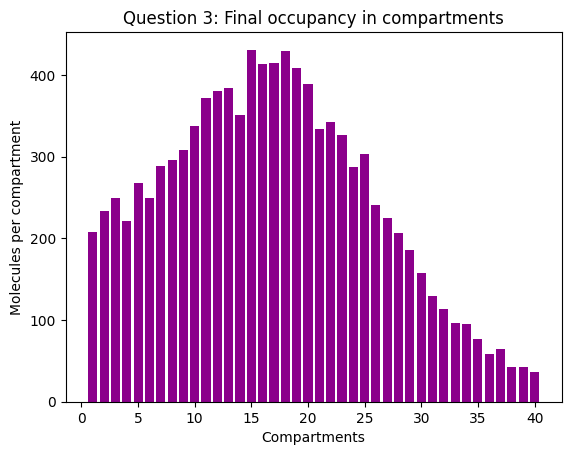

In [16]:
plt.bar(np.arange(1, 41), A, color = "darkmagenta")
plt.ylabel("Molecules per compartment")
plt.xlabel("Compartments")
plt.title("Question 3: Final occupancy in compartments")
plt.savefig("Question3.pdf")

In [17]:
# PART 2 : QUESTION 5
@jit
def schnakenberg_system():
    K = 40 # number of compartments
    L = 1
    h = L / K # compartment size
    Da = 1e-5 # diffusion coefficient of A
    Db = 1e-3 # diffusion coefficient of B
    
    k1 = 1e-4 * h * h
    k2 = 0.1 / h
    k3 = 0.02
    k4 = 0.3 / h
    kA = 2 * Da / (h * h)
    kB = 2 * Db / (h * h)
    
    A = np.full(K, 200)
    B = np.full(K, 75)
    
    prop1 = np.zeros(K)
    prop3 = np.zeros(K)
    propA = np.zeros(K)
    propB = np.zeros(K)
    total_prop = 0
    
    t = 0 
    T = 1800 # 30 minutes
    
    # set the initial conditions
    for i in range(K):
        prop1[i] = k1 * A[i] * (A[i] - 1) *  B[i]
        prop3[i] = k3 * A[i]
        propA[i] = kA * A[i]
        propB[i] = kB * B[i]
        total_prop += prop1[i] + k2 + prop3[i] + k4 + propA[i] + propB[i]
        
    while t < T:
        # time to next reaction
        tau = np.random.exponential(1 / total_prop)
        t = t + tau
        # generate random number
        rand = np.random.uniform(0, 1) * total_prop
        cumulative = 0 
        found_reaction = False
        
        # considering only one reaction happens at a time
        
        # Reaction 1
        i = 0 
        while i <= K and not found_reaction:
            cumulative += prop1[i]
            if cumulative >=  rand:
                # reaction happens
                total_prop -= prop1[i] + prop3[i] + propA[i] + propB[i]
                A[i] += 1
                B[i] -= 1
                # update propensities
                prop1[i] = k1 * A[i] * (A[i] - 1) *  B[i]
                prop3[i] = k3 * A[i]
                propA[i] = kA * A[i]
                propB[i] = kB * B[i]
                # update total with propensities that are affected by this reaction
                total_prop += prop1[i] + prop3[i] + propA[i] + propB[i]
                # tell whether a reaction occured
                found_reaction = True
            i += 1
            
        # Reaction 2
        i = 0
        while i <= K and not found_reaction:
            cumulative += k2
            if cumulative >= rand:
                # reaction happens
                total_prop -= prop1[i] + prop3[i] + propA[i]
                A[i] += 1
                # update affected propensities
                prop1[i] = k1 * A[i] * (A[i] - 1) *  B[i]
                prop3[i] = k3 * A[i]
                propA[i] = kA * A[i]
                # update total
                total_prop += prop1[i] + prop3[i] + propA[i]
                # reaction ocurred
                found_reaction = True
            i += 1
            
        # Reaction 3 
        i = 0
        while i <= K and not found_reaction:
            cumulative += prop3[i]
            if cumulative >= rand:
                # reaction happens
                total_prop -= prop1[i] + prop3[i] + propA[i]
                A[i] -= 1
                # update
                prop1[i] = k1 * A[i] * (A[i] - 1) * B[i]
                prop3[i] = k3 * A[i]
                propA[i] = kA * A[i]
                # update total 
                total_prop += prop1[i] + prop3[i] + propA[i]
                # reaction ocurred 
                found_reaction = True
            i += 1
            
        # Reaction 4
        i = 0
        while i <= K and not found_reaction:
            cumulative += k4
            if cumulative >= rand:
                # reaction happens
                total_prop -= prop1[i] + propB[i]
                B[i] += 1
                #update affected
                prop1[i] = k1 * A[i] * (A[i] - 1) * B[i]
                propB[i] = kB * B[i]
                # update total with affected
                total_prop += prop1[i] + propB[i]
                # reaction ocurred 
                found_reaction = True
            i += 1
        
        # Diffusion of A
        i = 0 
        while i <= K and not found_reaction:
            cumulative += propA[i]
            if cumulative >= rand:
                # diffusion happens, now determine direction
                direction = np.random.uniform(0,1)
                # difuses left from i -> i -1 
                if direction < 0.5 and i > 0:
                    total_prop -= prop1[i] + prop1[i - 1] + prop3[i] + prop3[ i - 1] + propA[i] + propA[i -1]
                    A[i] -= 1
                    A[i - 1] += 1
                    # update affected propensities for both compartments
                    prop1[i] = k1 * A[i] * (A[i] - 1) * B[i]
                    prop1[i - 1] = k1 * A[i - 1] * (A[i - 1] - 1) * B[i - 1]
                    prop3[i] = k3 * A[i]
                    prop3[i - 1] = k3 * A[i - 1]
                    propA[i] = kA * A[i]
                    propA[i - 1] = kA * A[i - 1]
                    # update all
                    total_prop += prop1[i] + prop1[i - 1] + prop3[i] + prop3[ i - 1] + propA[i] + propA[i -1]
                    found_reaction = True
                    # difuses right from i -> i + 1
                elif direction >= 0.5 and i < K-1:
                    total_prop -= prop1[i] + prop1[i + 1] + prop3[i] + prop3[ i + 1] + propA[i] + propA[i + 1]
                    A[i] -= 1
                    A[i + 1] += 1
                    # update affected propensities for both compartments
                    prop1[i] = k1 * A[i] * (A[i] - 1) * B[i]
                    prop1[i + 1] = k1 * A[i + 1] * (A[i + 1] - 1) * B[i + 1]
                    prop3[i] = k3 * A[i]
                    prop3[i + 1] = k3 * A[i + 1]
                    propA[i] = kA * A[i]
                    propA[i + 1] = kA * A[i + 1]
                    # update all
                    total_prop += prop1[i] + prop1[i + 1] + prop3[i] + prop3[ i + 1] + propA[i] + propA[i + 1]
                    found_reaction = True
                else:
                      found_reaction = True  
            i += 1
        
        # Difussion of B
        i = 0 
        while i <= K and not found_reaction:
            cumulative += propB[i]
            if cumulative >= rand:
                # diffusion happens, now determine direction
                direction = np.random.uniform(0,1)
                # difuses left from i -> i -1 
                if direction < 0.5 and i > 0:
                    total_prop -= prop1[i] + prop1[i - 1] + propB[i] + propB[i -1]
                    B[i] -= 1
                    B[i - 1] += 1
                    # update affected propensities for both compartments
                    prop1[i] = k1 * A[i] * (A[i] - 1) * B[i]
                    prop1[i - 1] = k1 * A[i - 1] * (A[i - 1] - 1) * B[i - 1]
                    propB[i] = kB * B[i]
                    propB[i - 1] = kB * B[i - 1]
                    # update all
                    total_prop += prop1[i] + prop1[i - 1] + propB[i] + propB[i -1]
                    found_reaction = True
                    # difuses right from i -> i + 1
                elif direction >= 0.5 and i < K-1:
                    total_prop -= prop1[i] + prop1[i + 1] + propB[i] + propB[i + 1]
                    B[i] -= 1
                    B[i + 1] += 1
                    # update affected propensities for both compartments
                    prop1[i] = k1 * A[i] * (A[i] - 1) * B[i]
                    prop1[i + 1] = k1 * A[i + 1] * (A[i + 1] - 1) * B[i + 1]
                    propB[i] = kB * B[i]
                    propB[i + 1] = kB * B[i + 1]
                    # update all
                    total_prop += prop1[i] + prop1[i + 1] + propB[i] + propB[i + 1]
                    found_reaction = True
                else:
                    found_reaction = True
            i += 1
            
        # no reaction
        if not found_reaction:
            raise RuntimeError("No reaction found!")
    
    return A, B

/var/folders/1d/b5lpmqbx325cjvrjtm3hlv380000gn/T/ipykernel_68335/1237594352.py:2: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit


In [18]:
A, B = schnakenberg_system()

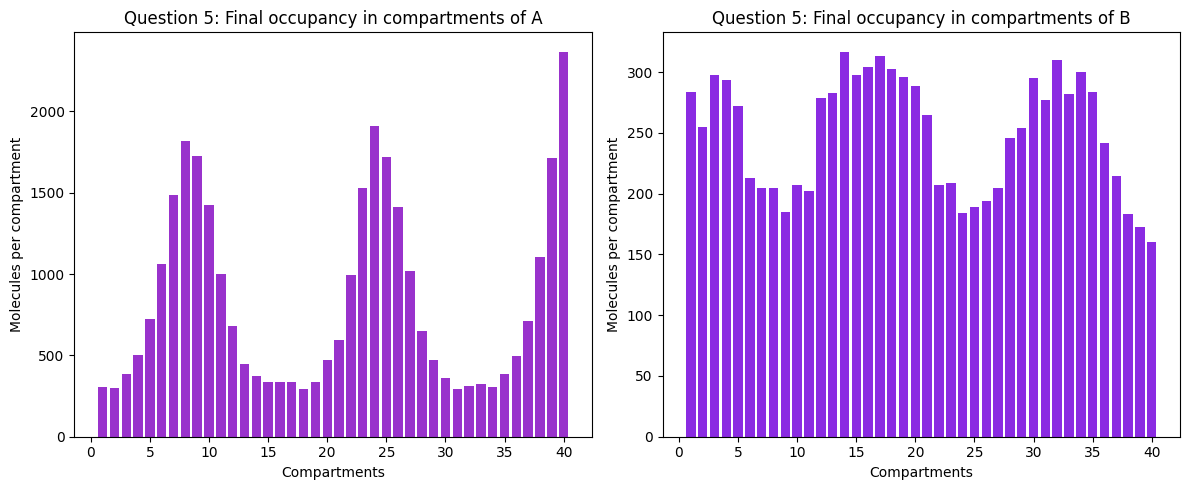

In [20]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.bar(range(1, 41), A, color='darkorchid')
plt.title('Question 5: Final occupancy in compartments of A')
plt.xlabel('Compartments')
plt.ylabel('Molecules per compartment')
plt.savefig("Question5A.pdf")

plt.subplot(1,2,2)
plt.bar(range(1,41), B, color='blueviolet')
plt.title('Question 5: Final occupancy in compartments of B')
plt.xlabel('Compartments')
plt.ylabel('Molecules per compartment')
plt.savefig("Question5B.pdf")

plt.tight_layout()
plt.show()
